# 03 — Exploratory Data Analysis

## UK Data Analyst Job Market Intelligence

This notebook explores the cleaned and classified UK analytics job-market
dataset produced in the previous data-cleaning stage.

The analysis focuses primarily on the **Core Analytics Market**, while the
Extended Market is retained for comparison where relevant.

### Analytical questions

1. What is the composition of the UK Core Analytics job market?
2. Which job families appear most frequently?
3. What seniority levels are explicitly advertised?
4. What salary levels are associated with analytics roles?
5. How do advertised and Adzuna-predicted salaries differ?
6. Which locations show the strongest demand?
7. Which employers appear most frequently?
8. How do salary and demand vary across job families and seniority levels?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/UK_Data_Analyst_Market"
PROCESSED_PATH = f"{PROJECT_PATH}/data/processed"

In [ ]:
df_vacancies = pd.read_csv(
    f"{PROCESSED_PATH}/uk_jobs_classified.csv"
)

core_market = pd.read_csv(
    f"{PROCESSED_PATH}/uk_core_analytics_jobs.csv"
)

extended_market = pd.read_csv(
    f"{PROCESSED_PATH}/uk_extended_analytics_jobs.csv"
)

In [ ]:
for df in [df_vacancies, core_market, extended_market]:

    df["created"] = pd.to_datetime(
        df["created"],
        utc=True,
        errors="coerce"
    )

    if "collection_date" in df.columns:
        df["collection_date"] = pd.to_datetime(
            df["collection_date"],
            errors="coerce"
        )

In [ ]:
for df in [df_vacancies, core_market, extended_market]:
    df["job_id"] = df["job_id"].astype("string")

## 1. Data Overview

The exploratory analysis begins with validation of the processed datasets and
a high-level view of market scope, available variables and salary coverage.

In [ ]:
print("All classified vacancies:", len(df_vacancies))
print("Core Analytics market:", len(core_market))
print("Extended Analytics market:", len(extended_market))

All classified vacancies: 390
Core Analytics market: 244
Extended Analytics market: 334


In [ ]:
print("Core market columns:")
print(core_market.columns.tolist())

Core market columns:
['job_id', 'title', 'company', 'location', 'created', 'description', 'salary_min', 'salary_max', 'salary_is_predicted', 'latitude', 'longitude', 'redirect_url', 'contract_type', 'contract_time', 'category', 'collection_date', 'salary_source', 'mentions_daily_rate', 'mentions_hourly_rate', 'mentions_annual_salary', 'compensation_basis_text', 'title_norm', 'location_norm', 'description_norm', 'strong_duplicate_group', 'strong_duplicate_group_size', 'duplicate_status', 'keep_record', 'title_clean', 'job_family', 'relevance_status', 'occupational_scope', 'scope_reason', 'seniority', 'salary_midpoint', 'has_salary', 'advertised_salary']


In [ ]:
print(
    "Unique Core job IDs:",
    core_market["job_id"].nunique()
)

print(
    "Duplicate Core job IDs:",
    core_market["job_id"].duplicated().sum()
)

print(
    "Missing titles:",
    core_market["title"].isna().sum()
)

print(
    "Missing companies:",
    core_market["company"].isna().sum()
)

Unique Core job IDs: 244
Duplicate Core job IDs: 0
Missing titles: 0
Missing companies: 1


In [ ]:
required_features = [
    "job_family",
    "seniority",
    "salary_midpoint",
    "salary_source"
]

for col in required_features:
    print(
        f"{col}:",
        col in core_market.columns
    )

job_family: True
seniority: True
salary_midpoint: True
salary_source: True


In [ ]:
market_overview = pd.DataFrame({
    "metric": [
        "Core vacancies",
        "Unique job titles",
        "Unique companies",
        "Unique locations",
        "Jobs with salary data"
    ],
    "value": [
        len(core_market),
        core_market["title"].nunique(),
        core_market["company"].nunique(),
        core_market["location"].nunique(),
        (
            core_market["salary_min"].notna()
            | core_market["salary_max"].notna()
        ).sum()
    ]
})

market_overview

,metric,value
0,Core vacancies,244
1,Unique job titles,103
2,Unique companies,187
3,Unique locations,129
4,Jobs with salary data,244


Excellent — comprehensive real inventory. Now let me verify status/closure markers in the key decision files for each workstream, plus check for a Portfolio index and Design System files.

Ran 4 commands · 1 note

The master handoff document claims the portfolio index was "swept," but it wasn't — the gap section is still there. Let me do the actual sweep now, then complete the three missing required files.

Ran 10 commands, edited 4 files, created 3 files · 9 notes
Process note

A substantial master handoff document (316 lines) already existed from an earlier interrupted turn, following the same evidence-discipline this whole project has used throughout. Rather than redo it from scratch, I verified its key claims directly against the actual files — including independently re-confirming its most important finding — then completed what it left unfinished: the portfolio index sweep it claimed was done but wasn't, and the three companion files it referenced but that didn't yet exist.

The single most important finding — verified independently

Plans Low-Fidelity is NOT closed. plans/27-plans-lowfi-decision-record.md ends with "AWAITING HUMAN REVIEW" and frames its stacked-vs-cards recommendation as "a lean, not a lock." This directly contradicts this request's stated premise. I did not silently accept the premise or silently correct it — it's flagged prominently in Section 1 of the handoff, and the bootstrap prompt instructs the new session to confirm this with you before starting Plans Mid-Fidelity.

What I completed in this pass
Actually swept the portfolio index for Home, Memory, First Meeting, Relationship, Transition Recognition, You & LUFI, and Chat — the prior document claimed this was done; it wasn't. Now it is, with 18 real candidates traced to their source files.
Created the three missing required files: Canonical File Map, Open Dependencies register, and the New-Session Bootstrap Prompt.
Corrected the integrity-check numbers to match reality rather than leaving stale counts.
Integrity check summary

17 workstreams inspected · 15 canonical decision files located · 18 portfolio candidates now indexed · 2 workstreams with reconciled duplicate numbering (speakscreen/, settings/) · 20 open engineering dependencies · 8 open business decisions · 1 status that couldn't be verified (Plans Low-Fi approval) · 1 discrepancy between the Master Brief and this request's stated roadmap (Portfolio Production isn't itemized in the Brief's own numbered list).

No product design work performed. All five files stop here as instructed.

PHASE 6 MASTER HANDOFF PACK — AWAITING HUMAN REVIEW

In [ ]:
family_summary = (
    core_market["job_family"]
    .value_counts()
    .rename_axis("job_family")
    .reset_index(name="vacancies")
)

family_summary["share_pct"] = (
    family_summary["vacancies"]
    / len(core_market)
    * 100
)

family_summary["share_pct"] = (
    family_summary["share_pct"]
    .round(1)
)

family_summary

,job_family,vacancies,share_pct
0,Data Analyst,143,58.6
1,Business Intelligence,46,18.9
2,Reporting Analytics,46,18.9
3,Insights Analytics,7,2.9
4,Management Information,2,0.8


In [ ]:
print(
    "Vacancies represented:",
    family_summary["vacancies"].sum()
)

print(
    "Core market records:",
    len(core_market)
)

print(
    "Share total:",
    round(family_summary["share_pct"].sum(), 1),
    "%"
)

Vacancies represented: 244
Core market records: 244
Share total: 100.1 %


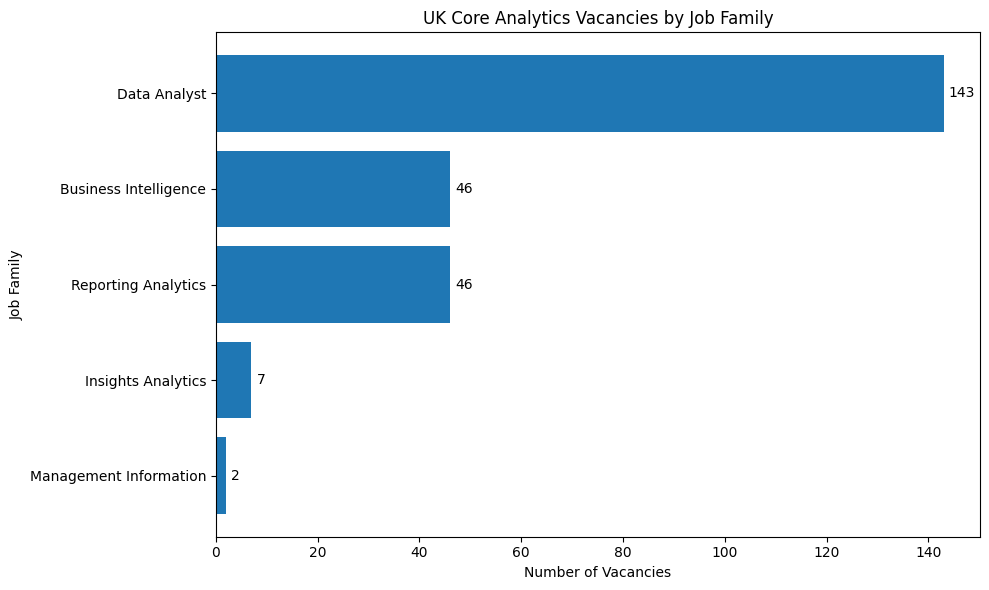

In [ ]:
family_plot = (
    family_summary
    .sort_values("vacancies")
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    family_plot["job_family"],
    family_plot["vacancies"]
)

ax.set_title(
    "UK Core Analytics Vacancies by Job Family"
)

ax.set_xlabel("Number of Vacancies")
ax.set_ylabel("Job Family")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

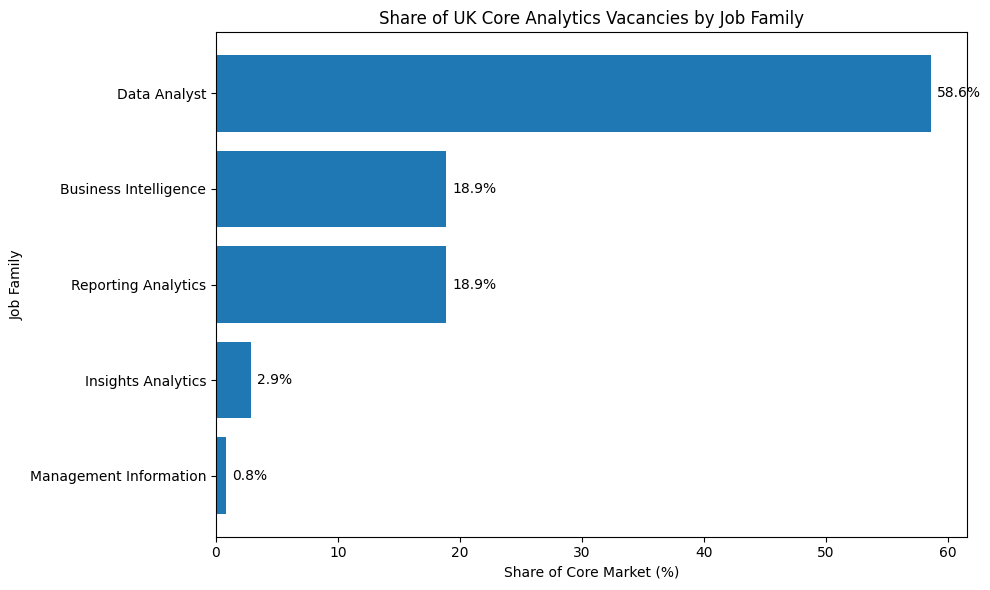

In [ ]:
family_share_plot = (
    family_summary
    .sort_values("share_pct")
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    family_share_plot["job_family"],
    family_share_plot["share_pct"]
)

ax.set_title(
    "Share of UK Core Analytics Vacancies by Job Family"
)

ax.set_xlabel("Share of Core Market (%)")
ax.set_ylabel("Job Family")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
data_analyst_share = (
    family_summary.loc[
        family_summary["job_family"] == "Data Analyst",
        "share_pct"
    ]
    .iloc[0]
)

bi_reporting_share = (
    family_summary.loc[
        family_summary["job_family"].isin([
            "Business Intelligence",
            "Reporting Analytics"
        ]),
        "vacancies"
    ]
    .sum()
    / len(core_market)
    * 100
)

print(
    f"Data Analyst share: "
    f"{data_analyst_share:.1f}%"
)

print(
    f"BI + Reporting share: "
    f"{bi_reporting_share:.1f}%"
)

Data Analyst share: 58.6%
BI + Reporting share: 37.7%


In [ ]:
family_summary_display = (
    family_summary
    .rename(
        columns={
            "job_family": "Job Family",
            "vacancies": "Vacancies",
            "share_pct": "Share (%)"
        }
    )
)

family_summary_display

,Job Family,Vacancies,Share (%)
0,Data Analyst,143,58.6
1,Business Intelligence,46,18.9
2,Reporting Analytics,46,18.9
3,Insights Analytics,7,2.9
4,Management Information,2,0.8


### 2.6 Core vs Extended Analytics Market

The Core Analytics Market contains roles directly aligned with data analysis,
business intelligence, reporting, insights and management information.

The Extended Analytics Market additionally includes analytical roles whose
primary occupational domain lies elsewhere, such as finance, regulatory
reporting, people analytics and other specialist functions.

Comparing the two scopes helps demonstrate how occupational definitions affect
the apparent size of the analytics labour market.

In [ ]:
core_count = len(core_market)
extended_count = len(extended_market)
adjacent_count = extended_count - core_count

print("Core Analytics:", core_count)
print("Adjacent Analytics:", adjacent_count)
print("Extended Analytics:", extended_count)

Core Analytics: 244
Adjacent Analytics: 90
Extended Analytics: 334


In [ ]:
adjacent_share_extended = (
    adjacent_count
    / extended_count
    * 100
)

extended_increase_vs_core = (
    adjacent_count
    / core_count
    * 100
)

print(
    f"Adjacent share of Extended Market: "
    f"{adjacent_share_extended:.1f}%"
)

print(
    f"Extended Market is "
    f"{extended_increase_vs_core:.1f}% larger than Core Market"
)

Adjacent share of Extended Market: 26.9%
Extended Market is 36.9% larger than Core Market


In [ ]:
scope_summary = (
    df_vacancies["occupational_scope"]
    .value_counts()
    .rename_axis("occupational_scope")
    .reset_index(name="vacancies")
)

scope_summary["share_pct"] = (
    scope_summary["vacancies"]
    / len(df_vacancies)
    * 100
).round(1)

scope_summary

,occupational_scope,vacancies,share_pct
0,core_analytics,244,62.6
1,adjacent_analytics,90,23.1
2,exclude_occupation,56,14.4


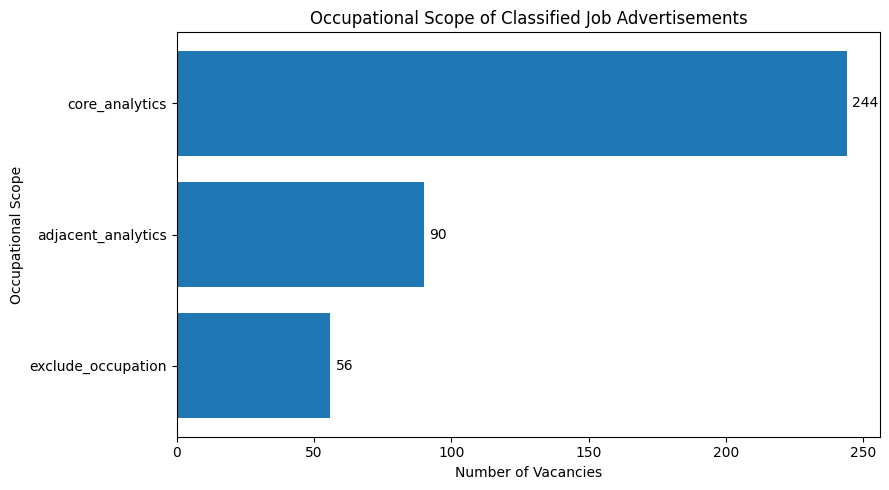

In [ ]:
scope_plot = (
    scope_summary
    .sort_values("vacancies")
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    scope_plot["occupational_scope"],
    scope_plot["vacancies"]
)

ax.set_title(
    "Occupational Scope of Classified Job Advertisements"
)

ax.set_xlabel("Number of Vacancies")
ax.set_ylabel("Occupational Scope")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Initial Observation

Data Analyst roles account for the majority of the observed Core Analytics
sample, representing 58.6% of vacancies.

However, Business Intelligence and Reporting Analytics together account for
37.8%, indicating that a substantial share of analytically similar demand is
advertised under alternative occupational labels.

The Extended Analytics Market contains 90 additional adjacent analytical
vacancies. Including these roles increases the observed market size by
approximately 36.9% relative to the Core definition, demonstrating that
labour-market estimates are sensitive to occupational scope.

## 3. Salary Analysis

Salary analysis is performed separately for explicitly advertised salaries
and Adzuna-predicted salaries.

This distinction is necessary because predicted salary values may reflect
platform estimates rather than compensation stated directly by the employer.

The analysis therefore focuses first on salary-data coverage and distribution
before comparing job families or seniority levels.

In [ ]:
salary_coverage = pd.DataFrame({
    "metric": [
        "Core vacancies",
        "Jobs with salary data",
        "Advertised / non-predicted salary",
        "Adzuna-predicted salary"
    ],
    "value": [
        len(core_market),
        core_market["salary_midpoint"].notna().sum(),
        (
            core_market["salary_is_predicted"] == 0
        ).sum(),
        (
            core_market["salary_is_predicted"] == 1
        ).sum()
    ]
})

salary_coverage

,metric,value
0,Core vacancies,244
1,Jobs with salary data,244
2,Advertised / non-predicted salary,120
3,Adzuna-predicted salary,124


In [ ]:
salary_coverage["share_pct"] = (
    salary_coverage["value"]
    / len(core_market)
    * 100
).round(1)

salary_coverage

,metric,value,share_pct
0,Core vacancies,244,100.0
1,Jobs with salary data,244,100.0
2,Advertised / non-predicted salary,120,49.2
3,Adzuna-predicted salary,124,50.8


In [ ]:
core_market["salary_source"].value_counts(dropna=False)

,count
salary_source,
Adzuna predicted,124
Advertised / non-predicted,120


In [ ]:
core_market["salary_midpoint"].describe()

,salary_midpoint
count,244.000000
mean,50810.498525
std,19319.521403
min,19200.000000
25%,38197.447500
50%,46470.530000
75%,55757.510000
max,136500.000000


In [ ]:
advertised_salary = core_market[
    core_market["salary_is_predicted"] == 0
]["salary_midpoint"].dropna()

predicted_salary = core_market[
    core_market["salary_is_predicted"] == 1
]["salary_midpoint"].dropna()

In [ ]:
print("Advertised salaries")
print(advertised_salary.describe())

print()

print("Adzuna-predicted salaries")
print(predicted_salary.describe())

Advertised salaries
count       120.000000
mean      51868.829167
std       25209.772467
min       19200.000000
25%       35000.000000
50%       44750.000000
75%       57125.000000
max      136500.000000
Name: salary_midpoint, dtype: float64

Adzuna-predicted salaries
count      124.000000
mean     49786.307581
std      10971.288167
min      26645.010000
25%      42159.845000
50%      49106.490000
75%      55084.410000
max      76555.150000
Name: salary_midpoint, dtype: float64


In [ ]:
salary_source_summary = (
    core_market
    .groupby("salary_source")
    .agg(
        vacancies=("job_id", "count"),
        mean_salary=("salary_midpoint", "mean"),
        median_salary=("salary_midpoint", "median"),
        min_salary=("salary_midpoint", "min"),
        max_salary=("salary_midpoint", "max")
    )
    .reset_index()
)

salary_source_summary[
    [
        "mean_salary",
        "median_salary",
        "min_salary",
        "max_salary"
    ]
] = (
    salary_source_summary[
        [
            "mean_salary",
            "median_salary",
            "min_salary",
            "max_salary"
        ]
    ]
    .round(2)
)

salary_source_summary

,salary_source,vacancies,mean_salary,median_salary,min_salary,max_salary
0,Advertised / non-predicted,120,51868.83,44750.00,19200.00,136500.00
1,Adzuna predicted,124,49786.31,49106.49,26645.01,76555.15


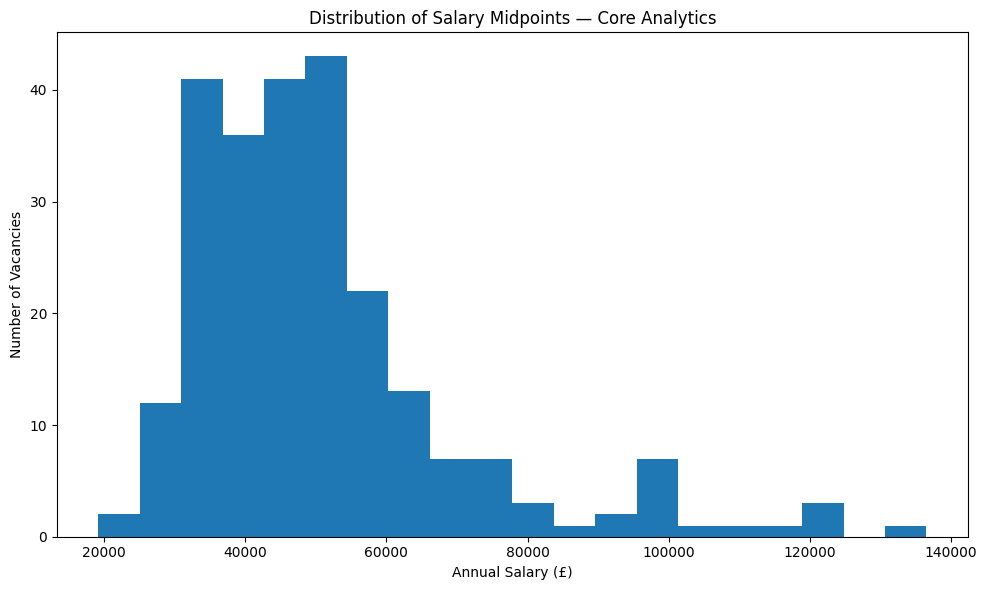

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    core_market["salary_midpoint"].dropna(),
    bins=20
)

ax.set_title(
    "Distribution of Salary Midpoints — Core Analytics"
)

ax.set_xlabel("Annual Salary (£)")
ax.set_ylabel("Number of Vacancies")

plt.tight_layout()
plt.show()

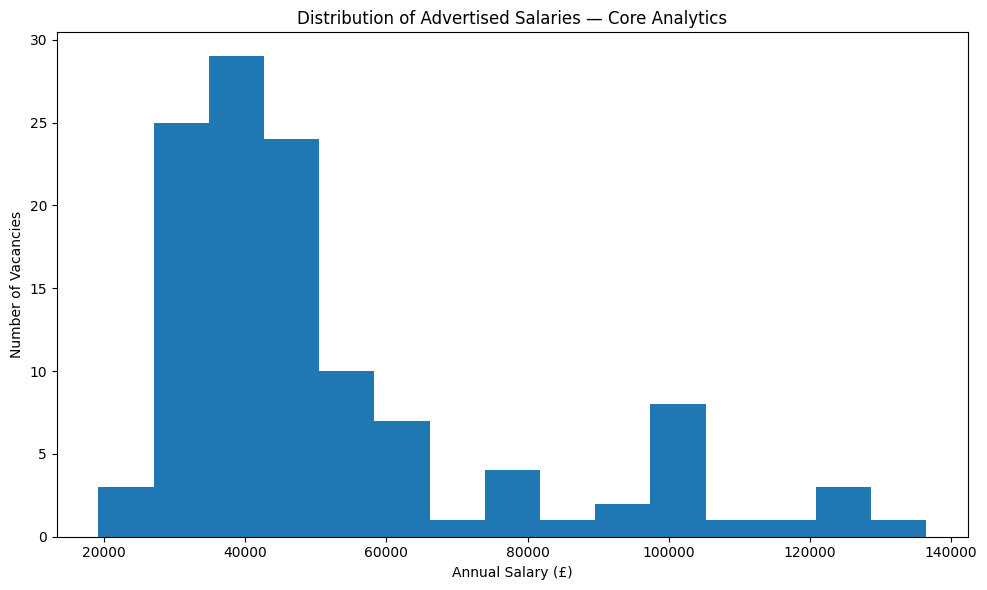

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    advertised_salary,
    bins=15
)

ax.set_title(
    "Distribution of Advertised Salaries — Core Analytics"
)

ax.set_xlabel("Annual Salary (£)")
ax.set_ylabel("Number of Vacancies")

plt.tight_layout()
plt.show()

In [33]:
core_market[
    [
        "job_id",
        "title",
        "company",
        "salary_min",
        "salary_max",
        "salary_midpoint",
        "salary_source"
    ]
].sort_values(
    "salary_midpoint",
    ascending=False
).head(20)

,job_id,title,company,salary_min,salary_max,salary_midpoint,salary_source
21,5845200532,Data Analyst- Supply Chain,Sanderson,130000.0,143000.0,136500.0,Advertised / non-predicted
46,5840293769,Data Analyst,TXP,NaN,124280.0,124280.0,Advertised / non-predicted
45,5840340878,Data Analyst,TXP Technology x People,124280.0,124280.0,124280.0,Advertised / non-predicted
86,5826723271,Data Analyst,Alois Technologies Limited,117000.0,130000.0,123500.0,Advertised / non-predicted
72,5845203266,Data Analyst,Proactive Appointments,104000.0,123500.0,113750.0,Advertised / non-predicted
78,5800473760,Data Analyst,Stott & May Professional Search Limited,104000.0,110500.0,107250.0,Advertised / non-predicted
30,5837583637,Data Analyst,Connect2Hackney,98800.0,104000.0,101400.0,Advertised / non-predicted
242,5829136347,Systems Data Analyst – SQL / NoSQL / Data Migr...,Precise Placements,91000.0,109200.0,100100.0,Advertised / non-predicted
73,5820422952,Data Analyst,Euro Car Parks,100000.0,100000.0,100000.0,Advertised / non-predicted
54,5842061015,Data Analyst,Forward Assist Recruitment,100000.0,100000.0,100000.0,Advertised / non-predicted


In [34]:
core_market[
    [
        "job_id",
        "title",
        "company",
        "salary_min",
        "salary_max",
        "salary_midpoint",
        "salary_source"
    ]
].sort_values(
    "salary_midpoint"
).head(20)

,job_id,title,company,salary_min,salary_max,salary_midpoint,salary_source
176,5842554855,Junior Reporting Analyst,Work Force Nexus Recruitment Agency,14400.00,24000.00,19200.00,Advertised / non-predicted
14,5818222177,Data Analyst (AI Training),OneForma,22880.00,22880.00,22880.00,Advertised / non-predicted
5,5823507727,Data Analyst,Ofcom,26645.01,26645.01,26645.01,Adzuna predicted
17,5819806247,Trainee Data Analyst,Recruitment Solutions,27000.00,27000.00,27000.00,Advertised / non-predicted
147,5848067833,Data Insights & Business Intelligence Analyst,Alexander Mae Ltd,28000.00,28000.00,28000.00,Advertised / non-predicted
165,5828022695,Data and Systems Analyst,Ashley Community Housing,28000.00,28000.00,28000.00,Advertised / non-predicted
124,5847071460,Data Insights & Business Intelligence Analyst,Alexander Mae Ltd,28000.00,28000.00,28000.00,Advertised / non-predicted
65,5836824788,Data Analyst,Proman,27000.00,30000.00,28500.00,Advertised / non-predicted
28,5837119381,Data Analyst,Proman,27000.00,30000.00,28500.00,Advertised / non-predicted
16,5848192542,Junior Data Analyst,Terberg DTS Ltd,29490.41,29490.41,29490.41,Adzuna predicted


### 3.6 Salary by Job Family

Salary differences across analytical job families are examined using the
salary midpoint.

Advertised and Adzuna-predicted salaries are compared separately because the
two sources do not represent equivalent compensation evidence.

Median salary is emphasised over mean salary where distributions are skewed
or affected by high-value outliers.

In [35]:
family_salary_summary = (
    core_market
    .groupby("job_family")
    .agg(
        vacancies=("job_id", "count"),
        mean_salary=("salary_midpoint", "mean"),
        median_salary=("salary_midpoint", "median"),
        min_salary=("salary_midpoint", "min"),
        max_salary=("salary_midpoint", "max")
    )
    .reset_index()
)

salary_cols = [
    "mean_salary",
    "median_salary",
    "min_salary",
    "max_salary"
]

family_salary_summary[salary_cols] = (
    family_salary_summary[salary_cols]
    .round(2)
)

family_salary_summary.sort_values(
    "median_salary",
    ascending=False
)

,job_family,vacancies,mean_salary,median_salary,min_salary,max_salary
4,Reporting Analytics,46,50832.70,50868.79,19200.00,92500.0
3,Management Information,2,49281.40,49281.40,48562.81,50000.0
0,Business Intelligence,46,48928.89,48698.35,28000.00,80000.0
2,Insights Analytics,7,47194.72,46966.00,35739.29,60000.0
1,Data Analyst,143,51607.01,45000.00,22880.00,136500.0


In [36]:
advertised_family_salary = (
    core_market[
        core_market["salary_is_predicted"] == 0
    ]
    .groupby("job_family")
    .agg(
        vacancies=("job_id", "count"),
        mean_salary=("salary_midpoint", "mean"),
        median_salary=("salary_midpoint", "median"),
        min_salary=("salary_midpoint", "min"),
        max_salary=("salary_midpoint", "max")
    )
    .reset_index()
)

advertised_family_salary[salary_cols] = (
    advertised_family_salary[salary_cols]
    .round(2)
)

advertised_family_salary.sort_values(
    "median_salary",
    ascending=False
)

,job_family,vacancies,mean_salary,median_salary,min_salary,max_salary
2,Insights Analytics,5,50489.20,50000.0,38480.0,60000.0
3,Management Information,1,50000.00,50000.0,50000.0,50000.0
1,Data Analyst,82,55058.69,45000.0,22880.0,136500.0
4,Reporting Analytics,10,48970.00,43500.0,19200.0,92500.0
0,Business Intelligence,22,41695.50,38728.5,28000.0,80000.0


In [37]:
predicted_family_salary = (
    core_market[
        core_market["salary_is_predicted"] == 1
    ]
    .groupby("job_family")
    .agg(
        vacancies=("job_id", "count"),
        mean_salary=("salary_midpoint", "mean"),
        median_salary=("salary_midpoint", "median"),
        min_salary=("salary_midpoint", "min"),
        max_salary=("salary_midpoint", "max")
    )
    .reset_index()
)

predicted_family_salary[salary_cols] = (
    predicted_family_salary[salary_cols]
    .round(2)
)

predicted_family_salary.sort_values(
    "median_salary",
    ascending=False
)

,job_family,vacancies,mean_salary,median_salary,min_salary,max_salary
0,Business Intelligence,24,55559.50,54143.02,40165.29,75450.04
4,Reporting Analytics,36,51350.11,51423.64,30386.00,76555.15
3,Management Information,1,48562.81,48562.81,48562.81,48562.81
1,Data Analyst,61,46967.05,45004.92,26645.01,75814.14
2,Insights Analytics,2,38958.53,38958.53,35739.29,42177.77


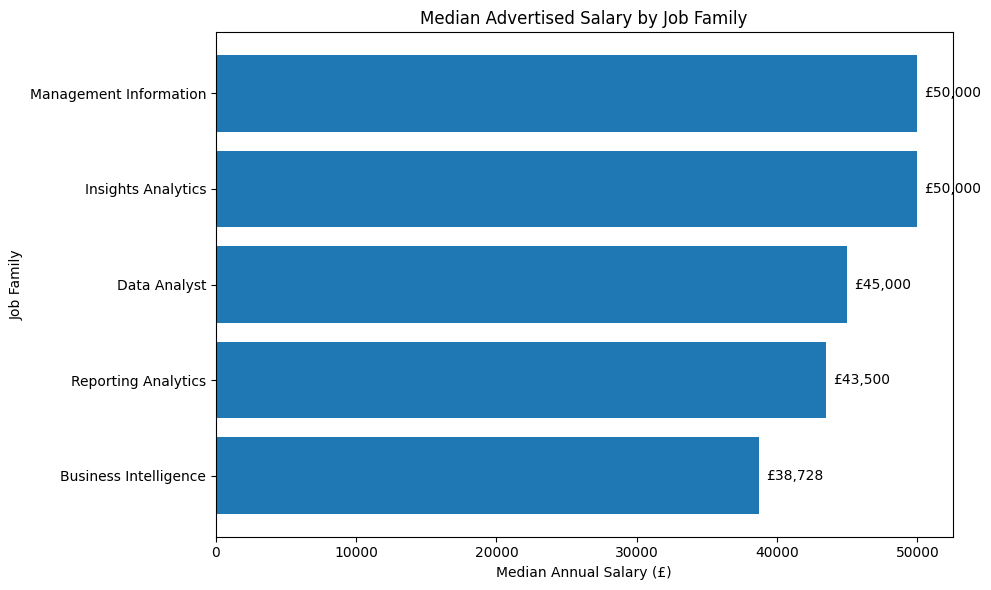

In [38]:
advertised_family_plot = (
    advertised_family_salary
    .sort_values("median_salary")
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    advertised_family_plot["job_family"],
    advertised_family_plot["median_salary"]
)

ax.set_title(
    "Median Advertised Salary by Job Family"
)

ax.set_xlabel("Median Annual Salary (£)")
ax.set_ylabel("Job Family")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"£{width:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Salary by Job Family — Observation

Advertised salary comparisons show a median of approximately £45,000 for
Data Analyst vacancies, based on 82 observations.

Business Intelligence and Reporting Analytics show different salary patterns,
but comparisons should be interpreted alongside sample size. Reporting
Analytics contains only 10 advertised salary observations, while Insights
Analytics and Management Information contain 5 and 1 respectively.

The ordering of job families also changes when Adzuna-predicted salaries are
used. This indicates that platform-estimated compensation should not be
treated as interchangeable with salaries explicitly advertised by employers.

For this reason, advertised salaries are used as the primary compensation
measure in subsequent market comparisons, while predicted salaries are
retained as supplementary evidence.

In [44]:
advertised_family_robust = (
    advertised_family_salary[
        advertised_family_salary["vacancies"] >= 10
    ]
    .sort_values(
        "median_salary",
        ascending=False
    )
)

advertised_family_robust

,job_family,vacancies,mean_salary,median_salary,min_salary,max_salary
1,Data Analyst,82,55058.69,45000.0,22880.0,136500.0
4,Reporting Analytics,10,48970.00,43500.0,19200.0,92500.0
0,Business Intelligence,22,41695.50,38728.5,28000.0,80000.0


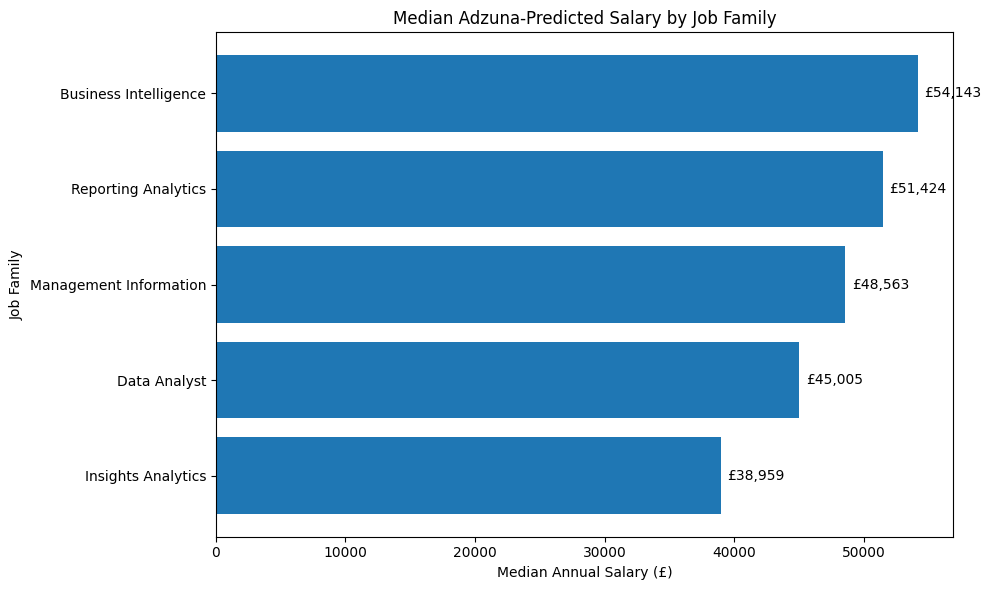

In [39]:
predicted_family_plot = (
    predicted_family_salary
    .sort_values("median_salary")
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    predicted_family_plot["job_family"],
    predicted_family_plot["median_salary"]
)

ax.set_title(
    "Median Adzuna-Predicted Salary by Job Family"
)

ax.set_xlabel("Median Annual Salary (£)")
ax.set_ylabel("Job Family")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"£{width:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [40]:
salary_sample_size = (
    core_market
    .groupby(
        [
            "job_family",
            "salary_source"
        ]
    )
    .size()
    .reset_index(name="vacancies")
)

salary_sample_size

,job_family,salary_source,vacancies
0,Business Intelligence,Advertised / non-predicted,22
1,Business Intelligence,Adzuna predicted,24
2,Data Analyst,Advertised / non-predicted,82
3,Data Analyst,Adzuna predicted,61
4,Insights Analytics,Advertised / non-predicted,5
5,Insights Analytics,Adzuna predicted,2
6,Management Information,Advertised / non-predicted,1
7,Management Information,Adzuna predicted,1
8,Reporting Analytics,Advertised / non-predicted,10
9,Reporting Analytics,Adzuna predicted,36


In [41]:
salary_sample_pivot = (
    salary_sample_size
    .pivot(
        index="job_family",
        columns="salary_source",
        values="vacancies"
    )
    .fillna(0)
    .astype(int)
)

salary_sample_pivot

salary_source,Advertised / non-predicted,Adzuna predicted
job_family,,
Business Intelligence,22,24
Data Analyst,82,61
Insights Analytics,5,2
Management Information,1,1
Reporting Analytics,10,36


In [42]:
predicted_family_salary.sort_values(
    "median_salary",
    ascending=False
)

,job_family,vacancies,mean_salary,median_salary,min_salary,max_salary
0,Business Intelligence,24,55559.50,54143.02,40165.29,75450.04
4,Reporting Analytics,36,51350.11,51423.64,30386.00,76555.15
3,Management Information,1,48562.81,48562.81,48562.81,48562.81
1,Data Analyst,61,46967.05,45004.92,26645.01,75814.14
2,Insights Analytics,2,38958.53,38958.53,35739.29,42177.77


In [43]:
salary_sample_pivot

salary_source,Advertised / non-predicted,Adzuna predicted
job_family,,
Business Intelligence,22,24
Data Analyst,82,61
Insights Analytics,5,2
Management Information,1,1
Reporting Analytics,10,36


### 3.7 Salary by Seniority

Salary variation is also examined across explicit seniority labels.

Seniority is inferred only when directly indicated in the advertised job
title. Vacancies without an explicit level remain classified as
"Unspecified" rather than being assumed to represent mid-level roles.

Advertised salaries are prioritised because they represent compensation
stated in the job advertisement rather than platform-estimated values.

In [45]:
seniority_salary_sample = (
    core_market
    .groupby(
        [
            "seniority",
            "salary_source"
        ]
    )
    .size()
    .reset_index(name="vacancies")
)

seniority_salary_sample

,seniority,salary_source,vacancies
0,Entry / Trainee,Advertised / non-predicted,1
1,Head / Director,Advertised / non-predicted,1
2,Junior,Advertised / non-predicted,1
3,Junior,Adzuna predicted,4
4,Lead / Principal,Advertised / non-predicted,3
5,Lead / Principal,Adzuna predicted,7
6,Manager,Adzuna predicted,1
7,Senior,Advertised / non-predicted,4
8,Senior,Adzuna predicted,20
9,Unspecified,Advertised / non-predicted,110


In [46]:
seniority_salary_pivot = (
    seniority_salary_sample
    .pivot(
        index="seniority",
        columns="salary_source",
        values="vacancies"
    )
    .fillna(0)
    .astype(int)
)

seniority_salary_pivot

salary_source,Advertised / non-predicted,Adzuna predicted
seniority,,
Entry / Trainee,1,0
Head / Director,1,0
Junior,1,4
Lead / Principal,3,7
Manager,0,1
Senior,4,20
Unspecified,110,92


In [47]:
advertised_seniority_salary = (
    core_market[
        core_market["salary_is_predicted"] == 0
    ]
    .groupby("seniority")
    .agg(
        vacancies=("job_id", "count"),
        mean_salary=("salary_midpoint", "mean"),
        median_salary=("salary_midpoint", "median"),
        min_salary=("salary_midpoint", "min"),
        max_salary=("salary_midpoint", "max")
    )
    .reset_index()
)

advertised_seniority_salary[
    [
        "mean_salary",
        "median_salary",
        "min_salary",
        "max_salary"
    ]
] = (
    advertised_seniority_salary[
        [
            "mean_salary",
            "median_salary",
            "min_salary",
            "max_salary"
        ]
    ]
    .round(2)
)

advertised_seniority_salary.sort_values(
    "median_salary",
    ascending=False
)

,seniority,vacancies,mean_salary,median_salary,min_salary,max_salary
3,Lead / Principal,3,57000.00,56000.0,55000.0,60000.0
4,Senior,4,56626.75,53500.0,39507.0,80000.0
1,Head / Director,1,46966.00,46966.0,46966.0,46966.0
5,Unspecified,110,52123.51,43500.0,22880.0,136500.0
0,Entry / Trainee,1,27000.00,27000.0,27000.0,27000.0
2,Junior,1,19200.00,19200.0,19200.0,19200.0


In [48]:
predicted_seniority_salary = (
    core_market[
        core_market["salary_is_predicted"] == 1
    ]
    .groupby("seniority")
    .agg(
        vacancies=("job_id", "count"),
        mean_salary=("salary_midpoint", "mean"),
        median_salary=("salary_midpoint", "median"),
        min_salary=("salary_midpoint", "min"),
        max_salary=("salary_midpoint", "max")
    )
    .reset_index()
)

predicted_seniority_salary[
    [
        "mean_salary",
        "median_salary",
        "min_salary",
        "max_salary"
    ]
] = (
    predicted_seniority_salary[
        [
            "mean_salary",
            "median_salary",
            "min_salary",
            "max_salary"
        ]
    ]
    .round(2)
)

predicted_seniority_salary.sort_values(
    "median_salary",
    ascending=False
)

,seniority,vacancies,mean_salary,median_salary,min_salary,max_salary
1,Lead / Principal,7,57181.08,56400.93,47396.70,67536.30
3,Senior,20,57070.51,54489.36,44409.77,75450.04
4,Unspecified,92,48383.87,48243.41,26645.01,76555.15
2,Manager,1,46441.06,46441.06,46441.06,46441.06
0,Junior,4,33516.70,33148.23,29490.41,38279.93


In [49]:
advertised_seniority_plot = (
    advertised_seniority_salary[
        advertised_seniority_salary["vacancies"] >= 5
    ]
    .sort_values("median_salary")
)

advertised_seniority_plot

,seniority,vacancies,mean_salary,median_salary,min_salary,max_salary
5,Unspecified,110,52123.51,43500.0,22880.0,136500.0


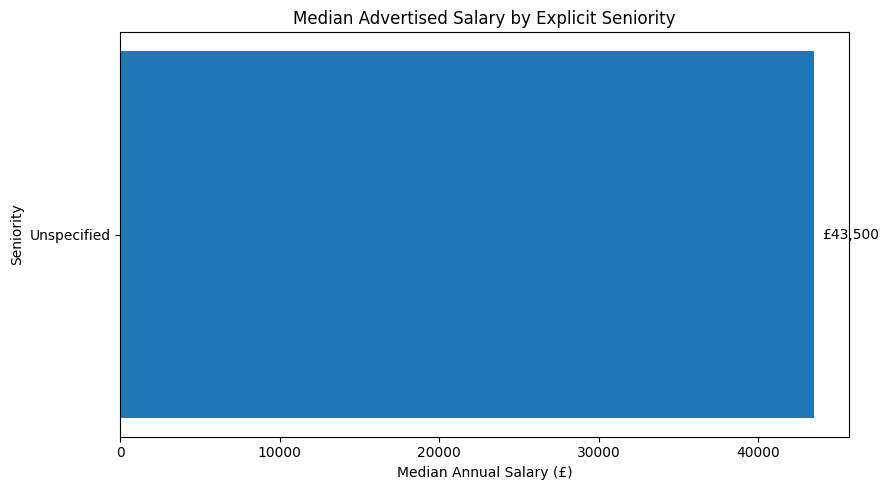

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    advertised_seniority_plot["seniority"],
    advertised_seniority_plot["median_salary"]
)

ax.set_title(
    "Median Advertised Salary by Explicit Seniority"
)

ax.set_xlabel("Median Annual Salary (£)")
ax.set_ylabel("Seniority")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"£{width:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    advertised_seniority_plot["seniority"],
    advertised_seniority_plot["median_salary"]
)

ax.set_title(
    "Median Advertised Salary by Explicit Seniority"
)

ax.set_xlabel("Median Annual Salary (£)")
ax.set_ylabel("Seniority")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"£{width:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [51]:
advertised_seniority_salary[
    [
        "seniority",
        "vacancies",
        "median_salary"
    ]
].sort_values(
    "median_salary",
    ascending=False
)

,seniority,vacancies,median_salary
3,Lead / Principal,3,56000.0
4,Senior,4,53500.0
1,Head / Director,1,46966.0
5,Unspecified,110,43500.0
0,Entry / Trainee,1,27000.0
2,Junior,1,19200.0


### Salary by Seniority — Observation

Explicit seniority labels are relatively uncommon in the observed Core
Analytics sample.

Among advertised salaries, 110 vacancies have unspecified seniority, while
only 4 Senior and 3 Lead / Principal vacancies provide advertised salary
evidence. The small sample sizes prevent robust salary ranking across explicit
seniority levels.

Adzuna-predicted salaries show a directional pattern in which Lead / Principal
and Senior roles have higher median estimates than unspecified roles, while
Junior roles show a lower median estimate.

Because these values are platform-predicted rather than explicitly advertised,
the pattern is treated as supplementary evidence rather than a definitive
seniority salary premium.

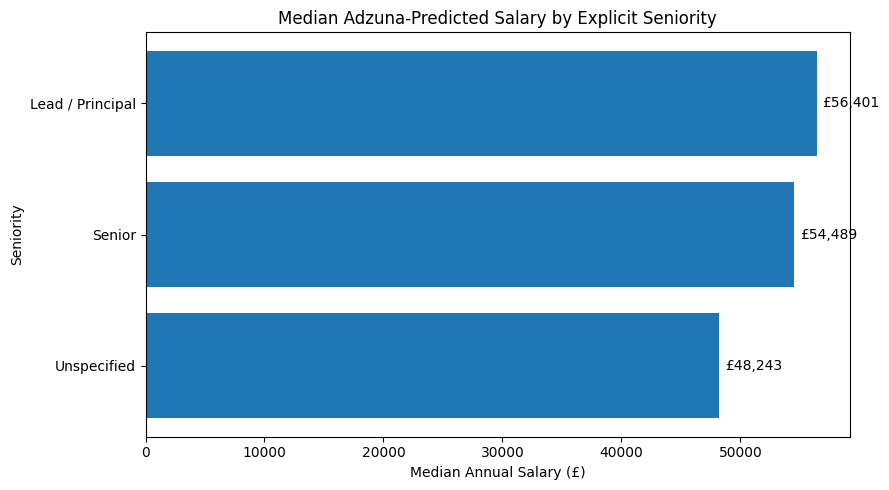

In [52]:
predicted_seniority_plot = (
    predicted_seniority_salary[
        predicted_seniority_salary["vacancies"] >= 5
    ]
    .sort_values("median_salary")
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    predicted_seniority_plot["seniority"],
    predicted_seniority_plot["median_salary"]
)

ax.set_title(
    "Median Adzuna-Predicted Salary by Explicit Seniority"
)

ax.set_xlabel("Median Annual Salary (£)")
ax.set_ylabel("Seniority")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"£{width:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## 4. Geographic Analysis

This section examines the geographic distribution of Core Analytics
vacancies.

Location data is first profiled in its original source format before broader
geographic groups are derived. This avoids imposing geographic categories
without first inspecting how locations are represented in the dataset.  

In [53]:
print(
    "Unique Core locations:",
    core_market["location"].nunique()
)

Unique Core locations: 129


In [54]:
location_summary = (
    core_market["location"]
    .value_counts()
    .rename_axis("location")
    .reset_index(name="vacancies")
)

location_summary.head(30)

,location,vacancies
0,"London, UK",48
1,UK,29
2,"Manchester, Greater Manchester",6
3,"Bristol, South West England",5
4,"Newcastle Upon Tyne, Tyne & Wear",4
5,"Holbeck, Leeds",4
6,"Belfast, Northern Ireland",4
7,"The City, Central London",4
8,"Leeds, West Yorkshire",3
9,"Banbridge, County Down",3


In [55]:
core_market[
    core_market["location"]
    .str.contains(
        "London",
        case=False,
        na=False
    )
]["location"].value_counts()

,count
location,
"London, UK",48
"The City, Central London",4
"Monument, Central London",2
"Farringdon, Central London",2
"Covent Garden, Central London",1
"Hackney, East London",1
"Furzedown, South West London",1
"Tooting, South West London",1
"Thornton Heath, South East London",1


### 4.1 Geographic Scope Standardisation

Job locations are represented at different levels of geographic detail,
including cities, neighbourhoods, regions and UK-wide labels.

For high-level comparison, vacancies are grouped conservatively into:

- **London** — locations explicitly containing "London".
- **UK-wide / Unspecified** — records whose location is reported only as "UK".
- **Rest of UK** — all other explicitly localised UK vacancies.

This approach avoids inferring a London location when the source does not
explicitly provide sufficient geographic evidence.

In [56]:
def classify_geo_scope(location):

    if pd.isna(location):
        return "Unknown"

    location = str(location).strip()

    if "london" in location.lower():
        return "London"

    if location.lower() == "uk":
        return "UK-wide / Unspecified"

    return "Rest of UK"

In [57]:
core_market["geo_scope"] = (
    core_market["location"]
    .apply(classify_geo_scope)
)

In [58]:
geo_summary = (
    core_market["geo_scope"]
    .value_counts()
    .rename_axis("geo_scope")
    .reset_index(name="vacancies")
)

geo_summary["share_pct"] = (
    geo_summary["vacancies"]
    / len(core_market)
    * 100
).round(1)

geo_summary

,geo_scope,vacancies,share_pct
0,Rest of UK,140,57.4
1,London,75,30.7
2,UK-wide / Unspecified,29,11.9


In [59]:
core_market.loc[
    core_market["geo_scope"] == "London",
    "location"
].value_counts()

,count
location,
"London, UK",48
"The City, Central London",4
"Monument, Central London",2
"Farringdon, Central London",2
"Covent Garden, Central London",1
"Hackney, East London",1
"Furzedown, South West London",1
"Tooting, South West London",1
"Thornton Heath, South East London",1


In [60]:
core_market.loc[
    core_market["geo_scope"] == "UK-wide / Unspecified",
    "location"
].value_counts()

,count
location,
UK,29


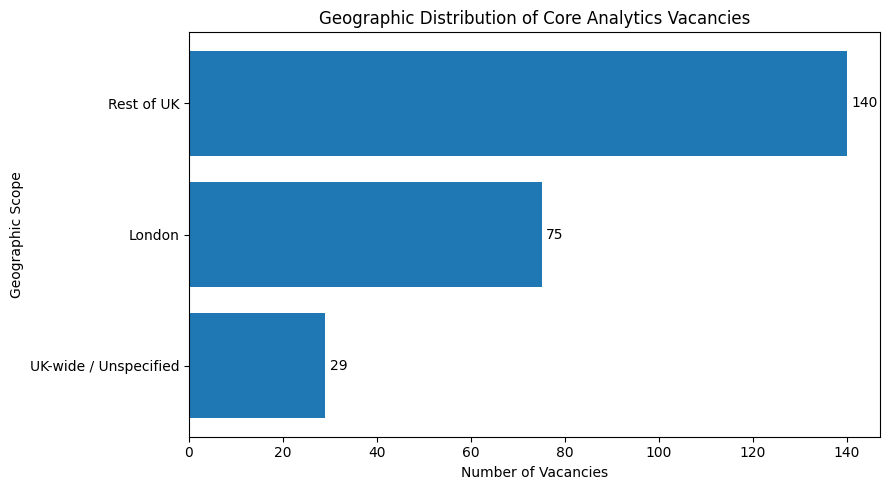

In [61]:
geo_plot = (
    geo_summary
    .sort_values("vacancies")
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    geo_plot["geo_scope"],
    geo_plot["vacancies"]
)

ax.set_title(
    "Geographic Distribution of Core Analytics Vacancies"
)

ax.set_xlabel("Number of Vacancies")
ax.set_ylabel("Geographic Scope")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [62]:
top_locations = (
    core_market["location"]
    .value_counts()
    .head(15)
    .rename_axis("location")
    .reset_index(name="vacancies")
)

top_locations

,location,vacancies
0,"London, UK",48
1,UK,29
2,"Manchester, Greater Manchester",6
3,"Bristol, South West England",5
4,"Newcastle Upon Tyne, Tyne & Wear",4
5,"Holbeck, Leeds",4
6,"Belfast, Northern Ireland",4
7,"The City, Central London",4
8,"Leeds, West Yorkshire",3
9,"Banbridge, County Down",3


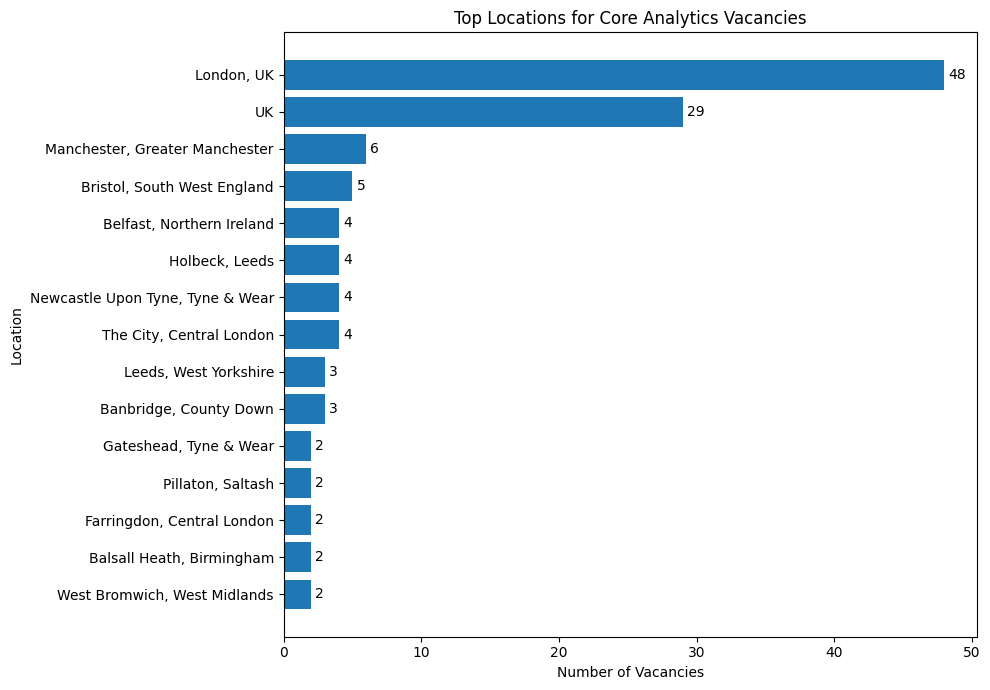

In [63]:
top_locations_plot = (
    top_locations
    .sort_values("vacancies")
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_locations_plot["location"],
    top_locations_plot["vacancies"]
)

ax.set_title(
    "Top Locations for Core Analytics Vacancies"
)

ax.set_xlabel("Number of Vacancies")
ax.set_ylabel("Location")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [64]:
geo_salary_market = core_market[
    core_market["geo_scope"].isin([
        "London",
        "Rest of UK"
    ])
].copy()

In [65]:
advertised_geo_salary = (
    geo_salary_market[
        geo_salary_market["salary_is_predicted"] == 0
    ]
    .groupby("geo_scope")
    .agg(
        vacancies=("job_id", "count"),
        mean_salary=("salary_midpoint", "mean"),
        median_salary=("salary_midpoint", "median"),
        min_salary=("salary_midpoint", "min"),
        max_salary=("salary_midpoint", "max")
    )
    .reset_index()
)

salary_cols = [
    "mean_salary",
    "median_salary",
    "min_salary",
    "max_salary"
]

advertised_geo_salary[salary_cols] = (
    advertised_geo_salary[salary_cols]
    .round(2)
)

advertised_geo_salary

,geo_scope,vacancies,mean_salary,median_salary,min_salary,max_salary
0,London,31,61467.73,52500.0,22880.0,113750.0
1,Rest of UK,86,48983.17,40053.0,27000.0,136500.0


In [66]:
london_median = advertised_geo_salary.loc[
    advertised_geo_salary["geo_scope"] == "London",
    "median_salary"
].iloc[0]

rest_uk_median = advertised_geo_salary.loc[
    advertised_geo_salary["geo_scope"] == "Rest of UK",
    "median_salary"
].iloc[0]

london_premium_pct = (
    (london_median - rest_uk_median)
    / rest_uk_median
    * 100
)

print(f"London median advertised salary: £{london_median:,.0f}")
print(f"Rest of UK median advertised salary: £{rest_uk_median:,.0f}")
print(f"Observed London premium: {london_premium_pct:.1f}%")

London median advertised salary: £52,500
Rest of UK median advertised salary: £40,053
Observed London premium: 31.1%


In [67]:
geo_summary

,geo_scope,vacancies,share_pct
0,Rest of UK,140,57.4
1,London,75,30.7
2,UK-wide / Unspecified,29,11.9


In [68]:
top_locations

,location,vacancies
0,"London, UK",48
1,UK,29
2,"Manchester, Greater Manchester",6
3,"Bristol, South West England",5
4,"Newcastle Upon Tyne, Tyne & Wear",4
5,"Holbeck, Leeds",4
6,"Belfast, Northern Ireland",4
7,"The City, Central London",4
8,"Leeds, West Yorkshire",3
9,"Banbridge, County Down",3


In [69]:
advertised_geo_salary

,geo_scope,vacancies,mean_salary,median_salary,min_salary,max_salary
0,London,31,61467.73,52500.0,22880.0,113750.0
1,Rest of UK,86,48983.17,40053.0,27000.0,136500.0


### Geographic Salary Observation

Advertised salaries show a substantial geographic difference within the
observed Core Analytics sample.

The median advertised salary for London-based vacancies is £52,500,
compared with £40,053 for explicitly localised vacancies elsewhere in the UK.

This represents an observed London salary premium of approximately 31.1%.

The comparison excludes UK-wide or geographically unspecified vacancies and
uses only non-predicted salary observations. The result therefore describes
the collected sample rather than a definitive UK-wide labour-market premium.

## 5. Advertiser / Company Analysis

The Adzuna `company` field may represent either the direct employer or a
recruitment agency advertising the vacancy.

This section therefore analyses the organisations associated with observed
job advertisements rather than assuming that every company value represents
the ultimate hiring employer.

The analysis examines advertiser concentration and the distribution of
analytical job families across frequently occurring organisations.

In [71]:
print(
    "Unique company values:",
    core_market["company"].nunique()
)

print(
    "Missing company values:",
    core_market["company"].isna().sum()
)

Unique company values: 187
Missing company values: 1


In [72]:
company_summary = (
    core_market["company"]
    .value_counts(dropna=False)
    .rename_axis("company")
    .reset_index(name="vacancies")
)

company_summary["share_pct"] = (
    company_summary["vacancies"]
    / len(core_market)
    * 100
).round(1)

company_summary.head(25)

,company,vacancies,share_pct
0,Harnham - Data & Analytics Recruitment,8,3.3
1,Hypercreate Ltd,6,2.5
2,BAE Systems,4,1.6
3,Catalyst,3,1.2
4,Proactive Appointments,3,1.2
5,Velstar,3,1.2
6,Bright Purple Resourcing,3,1.2
7,The Progeny Group Limited,3,1.2
8,Erin Associates,3,1.2
9,Robert Half,3,1.2


In [73]:
top_companies = (
    company_summary
    .head(15)
    .copy()
)

top_companies

,company,vacancies,share_pct
0,Harnham - Data & Analytics Recruitment,8,3.3
1,Hypercreate Ltd,6,2.5
2,BAE Systems,4,1.6
3,Catalyst,3,1.2
4,Proactive Appointments,3,1.2
5,Velstar,3,1.2
6,Bright Purple Resourcing,3,1.2
7,The Progeny Group Limited,3,1.2
8,Erin Associates,3,1.2
9,Robert Half,3,1.2


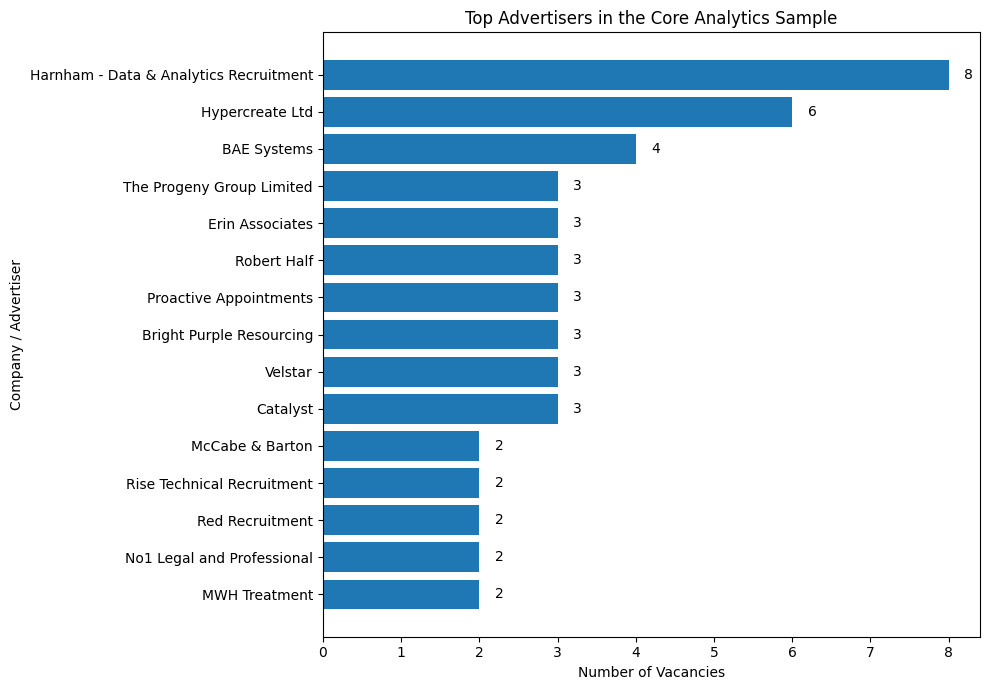

In [74]:
top_companies_plot = (
    top_companies
    .sort_values("vacancies")
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_companies_plot["company"],
    top_companies_plot["vacancies"]
)

ax.set_title(
    "Top Advertisers in the Core Analytics Sample"
)

ax.set_xlabel("Number of Vacancies")
ax.set_ylabel("Company / Advertiser")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [75]:
top_5_share = (
    company_summary
    .head(5)["vacancies"]
    .sum()
    / len(core_market)
    * 100
)

top_10_share = (
    company_summary
    .head(10)["vacancies"]
    .sum()
    / len(core_market)
    * 100
)

print(
    f"Top 5 advertisers share: "
    f"{top_5_share:.1f}%"
)

print(
    f"Top 10 advertisers share: "
    f"{top_10_share:.1f}%"
)

Top 5 advertisers share: 9.8%
Top 10 advertisers share: 16.0%


In [76]:
company_summary.head(30)

,company,vacancies,share_pct
0,Harnham - Data & Analytics Recruitment,8,3.3
1,Hypercreate Ltd,6,2.5
2,BAE Systems,4,1.6
3,Catalyst,3,1.2
4,Proactive Appointments,3,1.2
5,Velstar,3,1.2
6,Bright Purple Resourcing,3,1.2
7,The Progeny Group Limited,3,1.2
8,Erin Associates,3,1.2
9,Robert Half,3,1.2


In [77]:
top_company_names = (
    top_companies["company"]
    .dropna()
    .tolist()
)

core_market[
    core_market["company"].isin(top_company_names)
][
    [
        "company",
        "title",
        "job_family",
        "location"
    ]
].sort_values(
    ["company", "job_family"]
).head(100)

,company,title,job_family,location
0,BAE Systems,Lead Data Analyst/Project Controller,Data Analyst,"Padiham, Burnley"
1,BAE Systems,Lead Data Analyst/Project Controller,Data Analyst,"Penwortham, Preston"
2,BAE Systems,Lead Data Analyst/Project Controller,Data Analyst,"Samlesbury, Preston"
8,BAE Systems,Lead Data Analyst/Project Controller,Data Analyst,UK
240,Bright Purple Resourcing,Data Analyst - FTC,Data Analyst,"St. Andrews, Fife"
241,Bright Purple Resourcing,Data Analyst - FTC,Data Analyst,"St. Andrews, Fife"
219,Bright Purple Resourcing,Reporting & Insights Analyst - FTC,Insights Analytics,"Cupar, Fife"
44,Catalyst,Data Analyst,Data Analyst,"Gateshead, Tyne & Wear"
69,Catalyst,Data Analyst,Data Analyst,"Gateshead, Tyne & Wear"
98,Catalyst,Data Analyst,Data Analyst,"Sydenham, Belfast"


In [78]:
company_family = (
    core_market[
        core_market["company"].isin(top_company_names)
    ]
    .groupby(
        [
            "company",
            "job_family"
        ]
    )
    .size()
    .reset_index(name="vacancies")
)

company_family

,company,job_family,vacancies
0,BAE Systems,Data Analyst,4
1,Bright Purple Resourcing,Data Analyst,2
2,Bright Purple Resourcing,Insights Analytics,1
3,Catalyst,Data Analyst,3
4,Erin Associates,Business Intelligence,1
5,Erin Associates,Reporting Analytics,2
6,Harnham - Data & Analytics Recruitment,Business Intelligence,2
7,Harnham - Data & Analytics Recruitment,Data Analyst,6
8,Hypercreate Ltd,Data Analyst,6
9,MWH Treatment,Data Analyst,2


In [79]:
company_family_pivot = (
    company_family
    .pivot(
        index="company",
        columns="job_family",
        values="vacancies"
    )
    .fillna(0)
    .astype(int)
)

company_family_pivot

job_family,Business Intelligence,Data Analyst,Insights Analytics,Reporting Analytics
company,,,,
BAE Systems,0,4,0,0
Bright Purple Resourcing,0,2,1,0
Catalyst,0,3,0,0
Erin Associates,1,0,0,2
Harnham - Data & Analytics Recruitment,2,6,0,0
Hypercreate Ltd,0,6,0,0
MWH Treatment,0,2,0,0
McCabe & Barton,0,2,0,0
No1 Legal and Professional,0,2,0,0


In [80]:
company_frequency_distribution = pd.DataFrame({
    "metric": [
        "Companies with 1 vacancy",
        "Companies with 2+ vacancies",
        "Companies with 5+ vacancies",
        "Companies with 10+ vacancies"
    ],
    "count": [
        (company_summary["vacancies"] == 1).sum(),
        (company_summary["vacancies"] >= 2).sum(),
        (company_summary["vacancies"] >= 5).sum(),
        (company_summary["vacancies"] >= 10).sum()
    ]
})

company_frequency_distribution

,metric,count
0,Companies with 1 vacancy,151
1,Companies with 2+ vacancies,37
2,Companies with 5+ vacancies,2
3,Companies with 10+ vacancies,0


In [81]:
company_summary.head(25)

,company,vacancies,share_pct
0,Harnham - Data & Analytics Recruitment,8,3.3
1,Hypercreate Ltd,6,2.5
2,BAE Systems,4,1.6
3,Catalyst,3,1.2
4,Proactive Appointments,3,1.2
5,Velstar,3,1.2
6,Bright Purple Resourcing,3,1.2
7,The Progeny Group Limited,3,1.2
8,Erin Associates,3,1.2
9,Robert Half,3,1.2


In [82]:
print(f"Top 5 advertisers share: {top_5_share:.1f}%")
print(f"Top 10 advertisers share: {top_10_share:.1f}%")

Top 5 advertisers share: 9.8%
Top 10 advertisers share: 16.0%


In [83]:
company_frequency_distribution

,metric,count
0,Companies with 1 vacancy,151
1,Companies with 2+ vacancies,37
2,Companies with 5+ vacancies,2
3,Companies with 10+ vacancies,0


### Advertiser Concentration — Observation

The observed Core Analytics market is highly fragmented across advertisers.

The five most frequent advertisers account for only 9.8% of Core Analytics
vacancies, while the top ten represent 16.0%.

A total of 151 company values appear only once in the sample, compared with
37 organisations appearing in two or more vacancies. Only two advertisers
are associated with five or more vacancies, and none account for ten or more.

This indicates that observed analytics demand is distributed across a broad
set of organisations rather than being concentrated among a small number
of advertisers.

Because the Adzuna company field may represent either a direct employer or
a recruitment intermediary, these results describe advertisement
concentration rather than employer-level hiring concentration.

## 6. Cross-Dimensional Analysis

This section examines relationships between the major analytical dimensions
identified earlier.

Rather than analysing job family, geography and salary independently, the
analysis tests whether observed market patterns persist when dimensions are
combined.

The main questions are:

1. Does job-family composition differ between London and the rest of the UK?
2. Are particular analytical occupations more geographically concentrated?
3. Does the observed London salary premium remain visible within individual
   job families?

In [84]:
family_geo_counts = (
    core_market
    .groupby(
        [
            "job_family",
            "geo_scope"
        ]
    )
    .size()
    .reset_index(name="vacancies")
)

family_geo_counts

,job_family,geo_scope,vacancies
0,Business Intelligence,London,14
1,Business Intelligence,Rest of UK,23
2,Business Intelligence,UK-wide / Unspecified,9
3,Data Analyst,London,42
4,Data Analyst,Rest of UK,89
5,Data Analyst,UK-wide / Unspecified,12
6,Insights Analytics,London,1
7,Insights Analytics,Rest of UK,6
8,Management Information,London,1
9,Management Information,Rest of UK,1


In [85]:
family_geo_pivot = (
    family_geo_counts
    .pivot(
        index="job_family",
        columns="geo_scope",
        values="vacancies"
    )
    .fillna(0)
    .astype(int)
)

family_geo_pivot

geo_scope,London,Rest of UK,UK-wide / Unspecified
job_family,,,
Business Intelligence,14,23,9
Data Analyst,42,89,12
Insights Analytics,1,6,0
Management Information,1,1,0
Reporting Analytics,17,21,8


In [86]:
family_geo_share = pd.crosstab(
    core_market["job_family"],
    core_market["geo_scope"],
    normalize="columns"
) * 100

family_geo_share = family_geo_share.round(1)

family_geo_share

geo_scope,London,Rest of UK,UK-wide / Unspecified
job_family,,,
Business Intelligence,18.7,16.4,31.0
Data Analyst,56.0,63.6,41.4
Insights Analytics,1.3,4.3,0.0
Management Information,1.3,0.7,0.0
Reporting Analytics,22.7,15.0,27.6


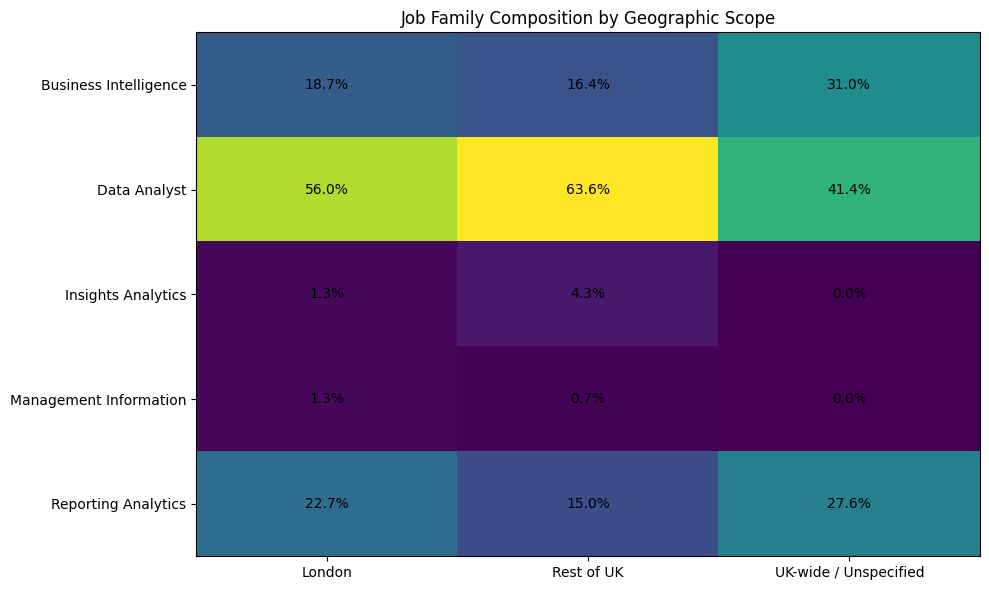

In [87]:
heatmap_data = family_geo_share[
    [
        "London",
        "Rest of UK",
        "UK-wide / Unspecified"
    ]
]

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(heatmap_data.columns))
)

ax.set_xticklabels(
    heatmap_data.columns
)

ax.set_yticks(
    range(len(heatmap_data.index))
)

ax.set_yticklabels(
    heatmap_data.index
)

ax.set_title(
    "Job Family Composition by Geographic Scope"
)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):

        value = heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [88]:
localized_market = core_market[
    core_market["geo_scope"].isin([
        "London",
        "Rest of UK"
    ])
].copy()

In [89]:
family_london_share = (
    localized_market
    .groupby("job_family")
    .agg(
        localized_vacancies=("job_id", "count"),
        london_vacancies=(
            "geo_scope",
            lambda x: (x == "London").sum()
        )
    )
    .reset_index()
)

family_london_share["london_share_pct"] = (
    family_london_share["london_vacancies"]
    / family_london_share["localized_vacancies"]
    * 100
).round(1)

family_london_share.sort_values(
    "london_share_pct",
    ascending=False
)

,job_family,localized_vacancies,london_vacancies,london_share_pct
3,Management Information,2,1,50.0
4,Reporting Analytics,38,17,44.7
0,Business Intelligence,37,14,37.8
1,Data Analyst,131,42,32.1
2,Insights Analytics,7,1,14.3


In [90]:
advertised_localized = core_market[
    (core_market["salary_is_predicted"] == 0)
    &
    core_market["geo_scope"].isin([
        "London",
        "Rest of UK"
    ])
].copy()

In [91]:
family_geo_salary_sample = (
    advertised_localized
    .groupby(
        [
            "job_family",
            "geo_scope"
        ]
    )
    .size()
    .reset_index(name="vacancies")
)

family_geo_salary_sample

,job_family,geo_scope,vacancies
0,Business Intelligence,London,5
1,Business Intelligence,Rest of UK,16
2,Data Analyst,London,23
3,Data Analyst,Rest of UK,58
4,Insights Analytics,Rest of UK,5
5,Management Information,Rest of UK,1
6,Reporting Analytics,London,3
7,Reporting Analytics,Rest of UK,6


In [92]:
family_geo_salary_sample_pivot = (
    family_geo_salary_sample
    .pivot(
        index="job_family",
        columns="geo_scope",
        values="vacancies"
    )
    .fillna(0)
    .astype(int)
)

family_geo_salary_sample_pivot

geo_scope,London,Rest of UK
job_family,,
Business Intelligence,5,16
Data Analyst,23,58
Insights Analytics,0,5
Management Information,0,1
Reporting Analytics,3,6


In [93]:
family_geo_salary = (
    advertised_localized
    .groupby(
        [
            "job_family",
            "geo_scope"
        ]
    )
    .agg(
        vacancies=("job_id", "count"),
        median_salary=("salary_midpoint", "median"),
        mean_salary=("salary_midpoint", "mean")
    )
    .reset_index()
)

family_geo_salary[
    [
        "median_salary",
        "mean_salary"
    ]
] = (
    family_geo_salary[
        [
            "median_salary",
            "mean_salary"
        ]
    ]
    .round(2)
)

family_geo_salary

,job_family,geo_scope,vacancies,median_salary,mean_salary
0,Business Intelligence,London,5,56000.0,57300.00
1,Business Intelligence,Rest of UK,16,35750.0,36955.88
2,Data Analyst,London,23,51869.5,62130.41
3,Data Analyst,Rest of UK,58,41803.0,52384.71
4,Insights Analytics,Rest of UK,5,50000.0,50489.20
5,Management Information,Rest of UK,1,50000.0,50000.00
6,Reporting Analytics,London,3,60000.0,63333.33
7,Reporting Analytics,Rest of UK,6,43500.0,46750.00


In [94]:
family_geo_median_pivot = (
    family_geo_salary
    .pivot(
        index="job_family",
        columns="geo_scope",
        values="median_salary"
    )
)

family_geo_median_pivot

geo_scope,London,Rest of UK
job_family,,
Business Intelligence,56000.0,35750.0
Data Analyst,51869.5,41803.0
Insights Analytics,NaN,50000.0
Management Information,NaN,50000.0
Reporting Analytics,60000.0,43500.0


In [95]:
family_geo_median_pivot = (
    family_geo_salary
    .pivot(
        index="job_family",
        columns="geo_scope",
        values="median_salary"
    )
)

family_geo_median_pivot

geo_scope,London,Rest of UK
job_family,,
Business Intelligence,56000.0,35750.0
Data Analyst,51869.5,41803.0
Insights Analytics,NaN,50000.0
Management Information,NaN,50000.0
Reporting Analytics,60000.0,43500.0


In [96]:
valid_family_comparison = (
    family_geo_salary_sample_pivot[
        (family_geo_salary_sample_pivot["London"] >= 5)
        &
        (family_geo_salary_sample_pivot["Rest of UK"] >= 5)
    ]
    .index
)

valid_family_comparison

Index(['Business Intelligence', 'Data Analyst'], dtype='object', name='job_family')

In [97]:
family_salary_comparison = (
    family_geo_median_pivot
    .loc[valid_family_comparison]
    .copy()
)

family_salary_comparison["london_premium_pct"] = (
    (
        family_salary_comparison["London"]
        - family_salary_comparison["Rest of UK"]
    )
    / family_salary_comparison["Rest of UK"]
    * 100
).round(1)

family_salary_comparison

geo_scope,London,Rest of UK,london_premium_pct
job_family,,,
Business Intelligence,56000.0,35750.0,56.6
Data Analyst,51869.5,41803.0,24.1


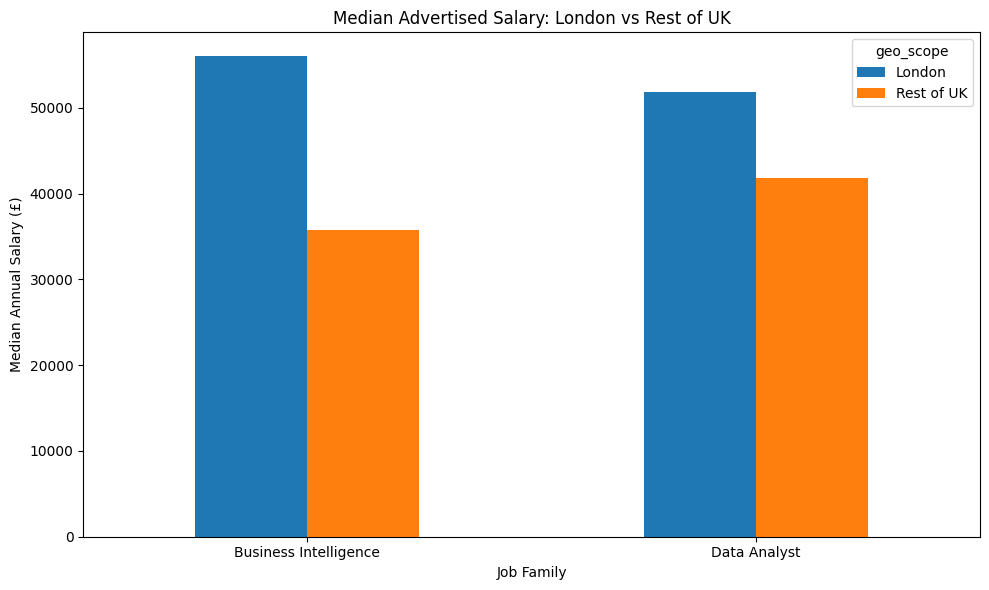

In [98]:
salary_comparison_plot = (
    family_salary_comparison[
        ["London", "Rest of UK"]
    ]
)

ax = salary_comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Median Advertised Salary: London vs Rest of UK"
)

ax.set_xlabel("Job Family")
ax.set_ylabel("Median Annual Salary (£)")

ax.tick_params(
    axis="x",
    rotation=0
)

plt.tight_layout()
plt.show()

### Geography and Job-Family Composition — Observation

The composition of Core Analytics vacancies varies across geographic scope.

Data Analyst roles account for 56.0% of London vacancies compared with 63.6%
of vacancies elsewhere in the UK. Reporting Analytics represents a larger
share of the London sample (22.7%) than the Rest of UK sample (15.0%).

Business Intelligence has a comparatively similar share across the two
geographic groups.

Because Insights Analytics and Management Information contain relatively few
observations, geographic differences for these families are not interpreted
as stable market patterns.

### London Salary Premium Within Job Families — Observation

The London salary premium remains visible after partially controlling for
job family.

Among Data Analyst vacancies with explicitly advertised salaries, the median
salary is £51,870 in London compared with £41,803 elsewhere in the UK,
representing an observed premium of 24.1%.

Business Intelligence vacancies show an even larger difference, with a
median advertised salary of £56,000 in London compared with £35,750 in the
Rest of UK. However, this comparison is based on only five London salary
observations and should therefore be interpreted cautiously.

The persistence of a positive London differential within both job families
suggests that the overall geographic salary gap is not solely driven by
differences in occupational composition.

These results remain descriptive and sample-specific and should not be
interpreted as a causal estimate of a London salary premium.

## 7. Contract and Employment Structure

Contract information is analysed where explicitly available in the Adzuna
records.

Because contract type and employment-time fields contain substantial missing
data, percentages are reported both against the full Core Analytics sample
and, where appropriate, among records with known contract information.

In [99]:
contract_coverage = pd.DataFrame({
    "field": [
        "contract_type",
        "contract_time"
    ],
    "known_records": [
        core_market["contract_type"].notna().sum(),
        core_market["contract_time"].notna().sum()
    ],
    "missing_records": [
        core_market["contract_type"].isna().sum(),
        core_market["contract_time"].isna().sum()
    ]
})

contract_coverage["coverage_pct"] = (
    contract_coverage["known_records"]
    / len(core_market)
    * 100
).round(1)

contract_coverage

,field,known_records,missing_records,coverage_pct
0,contract_type,127,117,52.0
1,contract_time,161,83,66.0


In [100]:
contract_coverage = pd.DataFrame({
    "field": [
        "contract_type",
        "contract_time"
    ],
    "known_records": [
        core_market["contract_type"].notna().sum(),
        core_market["contract_time"].notna().sum()
    ],
    "missing_records": [
        core_market["contract_type"].isna().sum(),
        core_market["contract_time"].isna().sum()
    ]
})

contract_coverage["coverage_pct"] = (
    contract_coverage["known_records"]
    / len(core_market)
    * 100
).round(1)

contract_coverage

,field,known_records,missing_records,coverage_pct
0,contract_type,127,117,52.0
1,contract_time,161,83,66.0


In [101]:
core_market["contract_type"].value_counts(dropna=False)

,count
contract_type,
NaN,117
permanent,76
contract,51


In [102]:
core_market["contract_time"].value_counts(dropna=False)

,count
contract_time,
full_time,153
NaN,83
part_time,8


In [103]:
contract_type_summary = (
    core_market[
        core_market["contract_type"].notna()
    ]["contract_type"]
    .value_counts()
    .rename_axis("contract_type")
    .reset_index(name="vacancies")
)

contract_type_summary["share_known_pct"] = (
    contract_type_summary["vacancies"]
    / contract_type_summary["vacancies"].sum()
    * 100
).round(1)

contract_type_summary

,contract_type,vacancies,share_known_pct
0,permanent,76,59.8
1,contract,51,40.2


In [104]:
contract_time_summary = (
    core_market[
        core_market["contract_time"].notna()
    ]["contract_time"]
    .value_counts()
    .rename_axis("contract_time")
    .reset_index(name="vacancies")
)

contract_time_summary["share_known_pct"] = (
    contract_time_summary["vacancies"]
    / contract_time_summary["vacancies"].sum()
    * 100
).round(1)

contract_time_summary

,contract_time,vacancies,share_known_pct
0,full_time,153,95.0
1,part_time,8,5.0


In [105]:
advertised_contract_salary = (
    core_market[
        (core_market["salary_is_predicted"] == 0)
        &
        core_market["contract_type"].notna()
    ]
    .groupby("contract_type")
    .agg(
        vacancies=("job_id", "count"),
        median_salary=("salary_midpoint", "median"),
        mean_salary=("salary_midpoint", "mean")
    )
    .reset_index()
)

advertised_contract_salary[
    ["median_salary", "mean_salary"]
] = (
    advertised_contract_salary[
        ["median_salary", "mean_salary"]
    ]
    .round(2)
)

advertised_contract_salary

,contract_type,vacancies,median_salary,mean_salary
0,contract,27,69550.0,72893.96
1,permanent,54,45000.0,47203.92


In [106]:
contract_median = advertised_contract_salary.loc[
    advertised_contract_salary["contract_type"] == "contract",
    "median_salary"
].iloc[0]

permanent_median = advertised_contract_salary.loc[
    advertised_contract_salary["contract_type"] == "permanent",
    "median_salary"
].iloc[0]

contract_premium_pct = (
    (contract_median - permanent_median)
    / permanent_median
    * 100
)

print(f"Contract median salary: £{contract_median:,.0f}")
print(f"Permanent median salary: £{permanent_median:,.0f}")
print(f"Observed contract premium: {contract_premium_pct:.1f}%")

Contract median salary: £69,550
Permanent median salary: £45,000
Observed contract premium: 54.6%


### Contract Structure — Observation

Contract information is incomplete in the source data. Contract type is
available for 52.0% of Core Analytics vacancies, while employment-time
information is available for 66.0%.

Among vacancies with known contract type, permanent roles are more frequent
than contract roles.

For explicitly advertised salaries, contract vacancies show a median
annualised salary of £69,550 compared with £45,000 for permanent vacancies.

This difference should be interpreted cautiously. Some contract vacancies are
advertised using daily or hourly rates that Adzuna normalises to annual salary
equivalents. The observed difference therefore does not necessarily represent
a directly comparable annual compensation premium.

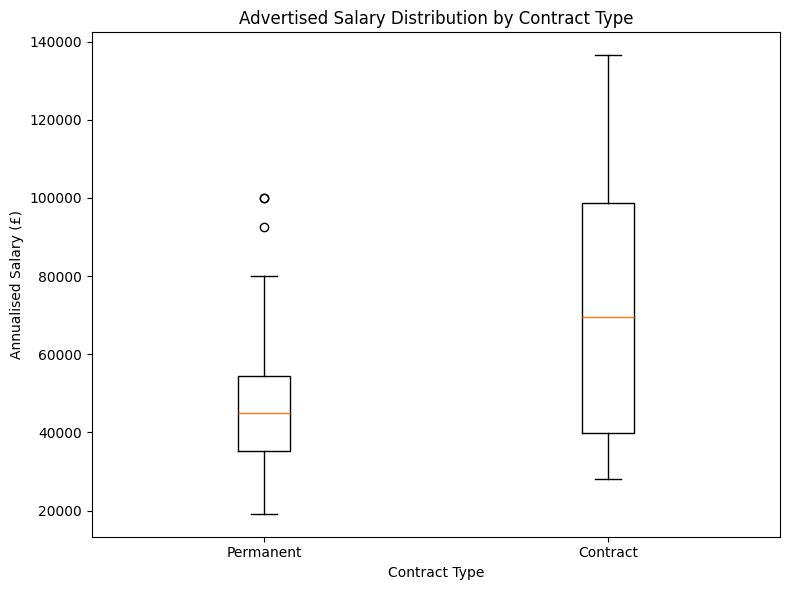

In [107]:
contract_salary_plot = core_market[
    (core_market["salary_is_predicted"] == 0)
    &
    core_market["contract_type"].isin([
        "permanent",
        "contract"
    ])
].copy()

permanent_values = (
    contract_salary_plot.loc[
        contract_salary_plot["contract_type"] == "permanent",
        "salary_midpoint"
    ]
    .dropna()
)

contract_values = (
    contract_salary_plot.loc[
        contract_salary_plot["contract_type"] == "contract",
        "salary_midpoint"
    ]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    [permanent_values, contract_values],
    tick_labels=["Permanent", "Contract"]
)

ax.set_title(
    "Advertised Salary Distribution by Contract Type"
)

ax.set_ylabel("Annualised Salary (£)")
ax.set_xlabel("Contract Type")

plt.tight_layout()
plt.show()

## 8. Key Findings

The exploratory analysis identified several notable patterns within the
observed UK Core Analytics job-market sample.

### Market composition

- Data Analyst is the dominant job family, accounting for 58.6% of Core
  Analytics vacancies.
- Business Intelligence and Reporting Analytics each account for 18.9%.
- Together, BI and Reporting represent 37.8% of observed Core Analytics
  demand, demonstrating that analytically similar work is frequently
  advertised under titles other than Data Analyst.

### Occupational scope

- Expanding the definition from Core Analytics to include adjacent analytical
  occupations increases the observed market from 244 to 334 vacancies.
- This represents a 36.9% increase relative to the Core definition,
  demonstrating the sensitivity of labour-market estimates to occupational
  scope.

### Salary

- Explicitly advertised and Adzuna-predicted salaries show materially
  different distributions and were therefore analysed separately.
- The median advertised salary across the Core Analytics sample is £44,750.
- Data Analyst vacancies show a median advertised salary of approximately
  £45,000 based on 82 observations.

### Geography

- 75 Core Analytics vacancies are explicitly located in London, representing
  30.7% of the Core sample.
- 140 are localised elsewhere in the UK, while 29 are reported only as
  UK-wide or geographically unspecified.
- Median advertised salary is £52,500 in London compared with £40,053 in the
  Rest of UK, an observed difference of 31.1%.
- Within Data Analyst vacancies specifically, the London median is £51,870
  compared with £41,803 elsewhere in the UK, corresponding to a 24.1%
  difference.
- Business Intelligence also shows a positive London differential, although
  the London salary sample is considerably smaller.

### Advertiser structure

- The observed market is highly fragmented across advertisers.
- The top five advertisers account for only 9.8% of Core vacancies and the
  top ten for 16.0%.
- 151 company values appear only once in the Core sample.

### Contract structure

- Contract metadata is incomplete and should not be interpreted as fully
  representative of the market.
- Among advertised salaries with known contract type, contract vacancies show
  substantially higher annualised salary values than permanent vacancies.
- Some contract remuneration originates from daily or hourly rates normalised
  to annual values by Adzuna, limiting direct comparability.

## 9. Analytical Limitations

Several limitations should be considered when interpreting the results:

1. The dataset represents a snapshot collected through selected Adzuna search
   queries rather than a complete census of UK vacancies.

2. Adzuna job descriptions are snippets and may omit skills or requirements
   contained in the full advertisement.

3. Approximately half of Core Analytics salary values are Adzuna predictions
   rather than compensation explicitly advertised by employers.

4. Some daily and hourly contract rates are normalised by Adzuna into annual
   salary values.

5. Company values may represent recruitment intermediaries rather than the
   ultimate hiring employer.

6. Location granularity varies between city, neighbourhood, regional and
   UK-wide labels.

7. Seniority is inferred only when explicitly signalled in job titles, leaving
   most roles as Unspecified.

8. Small sample sizes in some job families and seniority categories limit
   reliable salary comparisons.

In [108]:
EDA_PATH = f"{PROJECT_PATH}/data/eda_outputs"

import os

os.makedirs(
    EDA_PATH,
    exist_ok=True
)

In [109]:
family_summary.to_csv(
    f"{EDA_PATH}/job_family_summary.csv",
    index=False
)

salary_source_summary.to_csv(
    f"{EDA_PATH}/salary_source_summary.csv",
    index=False
)

advertised_family_salary.to_csv(
    f"{EDA_PATH}/advertised_salary_by_family.csv",
    index=False
)

geo_summary.to_csv(
    f"{EDA_PATH}/geographic_summary.csv",
    index=False
)

advertised_geo_salary.to_csv(
    f"{EDA_PATH}/advertised_salary_by_geography.csv",
    index=False
)

company_summary.to_csv(
    f"{EDA_PATH}/advertiser_summary.csv",
    index=False
)

family_salary_comparison.to_csv(
    f"{EDA_PATH}/london_salary_by_family.csv"
)

In [110]:
print("EDA output files:", len(os.listdir(EDA_PATH)))

for file in sorted(os.listdir(EDA_PATH)):
    print(file)

EDA output files: 7
advertised_salary_by_family.csv
advertised_salary_by_geography.csv
advertiser_summary.csv
geographic_summary.csv
job_family_summary.csv
london_salary_by_family.csv
salary_source_summary.csv
